### Program 1

imports

In [212]:
import numpy
import keras
from math import sqrt
from keras import layers, Input, Model, optimizers
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from sklearn.model_selection import train_test_split
import numpy as np

plt.style.use('dark_background')


1. load data

In [296]:
with open("../resources/dane1.txt") as file:
    data = file.readlines()

x_data, y_data = zip(*[map(float, line.split()) for line in data])

print(f"X: {x_data}\n")
print(f"y: {y_data}")

X: (-2.0, -1.9, -1.8, -1.7, -1.6, -1.5, -1.4, -1.3, -1.2, -1.1, -1.0, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, -6.383782e-16, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0)

y: (4.051976, 3.426599, 3.403733, 3.065183, 2.551354, 2.270867, 2.008356, 1.835507, 1.327425, 1.127331, 0.8850988, 0.9486903, 0.7738474, 0.3261774, 0.2803469, 0.388177, 0.1626725, 0.1727981, 0.0903815, -0.09300252, 0.01705861, 0.02165437, 0.1308718, 0.2489937, 0.3368687, 0.3758846, 0.3604993, 0.5808921, 0.4526863, 0.9413238, 0.9496301, 1.278366, 1.401595, 1.725725, 2.110108, 2.280629, 2.604458, 2.878133, 3.174786, 3.482901, 4.067652)


2. split data into test and training sets

In [297]:
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2)

print(f"X_train | size: {len(X_train)}, values: {X_train}\n")
print(f"y_train: {y_train}\n")
print(f"X_test | size: {len(X_test)}, values: {X_test}\n")
print(f"y_test: {y_test}")

X_train | size: 32, values: [-0.6, 1.1, -1.0, 1.2, -1.3, -6.383782e-16, 0.1, 0.3, 1.8, 0.6, -0.4, 1.5, 0.9, -0.2, 1.4, -0.1, 2.0, 0.8, 1.6, 1.7, -1.8, 1.0, -1.1, -1.4, -0.8, -0.5, -1.2, -0.3, -2.0, -0.7, 0.4, -1.5]

y_train: [0.2803469, 1.278366, 0.8850988, 1.401595, 1.835507, 0.01705861, 0.02165437, 0.2489937, 3.174786, 0.3604993, 0.1626725, 2.280629, 0.9413238, 0.0903815, 2.110108, -0.09300252, 4.067652, 0.4526863, 2.604458, 2.878133, 3.403733, 0.9496301, 1.127331, 2.008356, 0.7738474, 0.388177, 1.327425, 0.1727981, 4.051976, 0.3261774, 0.3368687, 2.270867]

X_test | size: 9, values: [0.7, 1.3, 0.5, -1.9, -0.9, 0.2, -1.6, -1.7, 1.9]

y_test: [0.5808921, 1.725725, 0.3758846, 3.426599, 0.9486903, 0.1308718, 2.551354, 3.065183, 3.482901]


3. plot test set, train set and original data

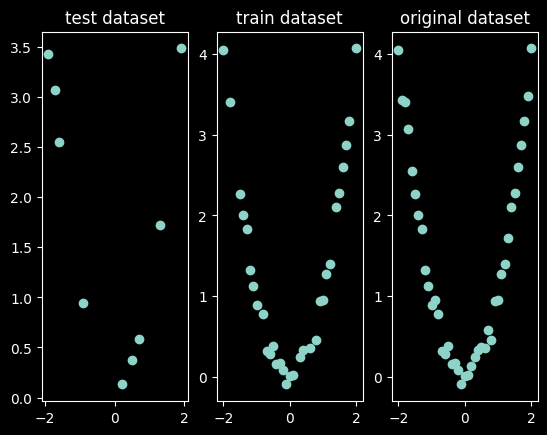

<Figure size 640x480 with 0 Axes>

In [298]:
_, (test_plot, train_plot, org_plot) = plt.subplots(1,3)

test_plot.scatter(X_test, y_test)
test_plot.set_title("test dataset")
train_plot.scatter(X_train, y_train)
train_plot.set_title("train dataset")
org_plot.scatter(x_data, y_data)
org_plot.set_title("original dataset")

plt.show()
plt.savefig("output/input_data.png")

9. format input data

In [299]:
def nest_and_put_into_np(flat_arr: list):
    nested_arr = []
    for element in flat_arr:
        nested_arr.append([element])
    return np.array(nested_arr, dtype="float32")

X_train_f = nest_and_put_into_np(X_train)
X_test_f = nest_and_put_into_np(X_test)
y_train_f = nest_and_put_into_np(y_train)
y_test_f = nest_and_put_into_np(y_test)


4. define the input layer

In [312]:
inputs = Input(shape=(1,), name="input_features")

4. define the hidden layers

In [313]:
x = layers.Dense(6, activation="relu", name="hidden_layer_1")(inputs)

# x = layers.Dense(2, activation="relu", name="hidden_layer_2")(x)

4. define the output layer

In [314]:
outputs = layers.Dense(1, name="predicted_value")(x)

5. build the model

In [315]:
model = Model(
    inputs=inputs,
    outputs=outputs,
    name="regression_model"
)

 6. plot model

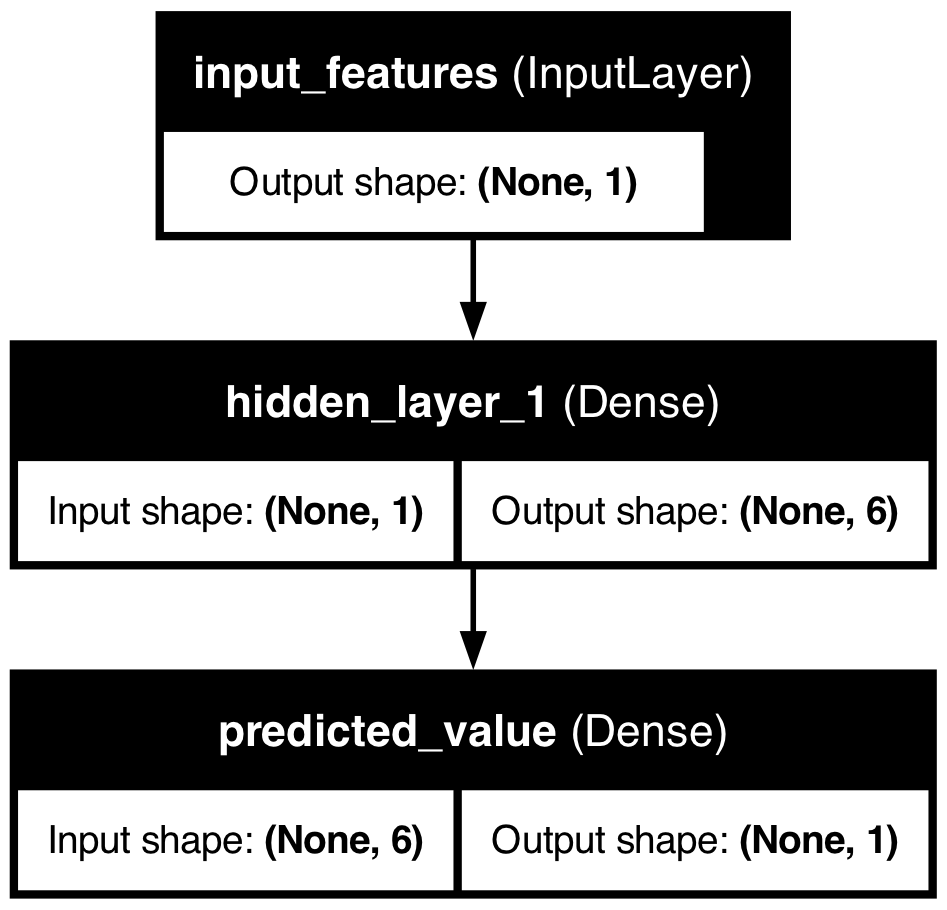

In [316]:
keras.utils.plot_model(
    model,
    "output/regression_model.png",
    show_shapes=True,
    show_layer_names=True
)

7. compile the model

In [318]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mse"]
)

8. check the model

In [319]:
print(
    model.summary()
)

Model: "regression_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 6)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predicted_value (Dense)         │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (76.00 B)

 Trainable params: 19 (76.00 B)

 Non-trainable params: 0 (0.00 B)

None


10. train model

In [345]:
# batch_size = int(sqrt(len(X_train_f)))
batch_size = int(len(X_train_f) / 4)

number_of_epochs = 80

def train(X_train_f, y_train_f):
    training_history = model.fit(
        X_train_f,
        y_train_f,
        epochs=number_of_epochs,
        batch_size=batch_size,
        validation_split=0.2
    )
    return training_history

train(X_train_f, y_train)

ValueError: Argument `validation_split` is only supported for tensors or NumPy arrays.Found incompatible type in the input: [<class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>, <class 'float'>]

11. check the training process

In [329]:
training_history.history

mse_values: list[float] = training_history.history["mse"]
last_mse = mse_values[len(mse_values) -1]
first_mse = mse_values[0]
print(f"mse improvement between first and last epoch | first_mse: {first_mse}, last_mse: {last_mse}, delta: {first_mse - last_mse}")

mse improvement between first and last epoch | first_mse: 0.19694006443023682, last_mse: 0.15872988104820251, delta: 0.0382101833820343


11. make predictions on test set

In [340]:
predictions = model.predict(X_test_f)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


12. evaluate model accuracy

For the regression problem a network with single hidden layer has been chosen. The layer has 6 neurons and a RELU activation function to prevent the linearity problem. In the training the ADAM function was used for recalculation of neurons weights. The training consisted of 80 epochs which is a local optimum, as a decline in accuracy over 100 epochs was observed. Additionally the batch size was set as one-forth of the train dataset size.
Configuration has yielded following results:
- The mean absolute error of training test is 0.345
- The validation loss decreased from 0.15868 observed after first epoch to 0.12794 observed after 80th epoch.


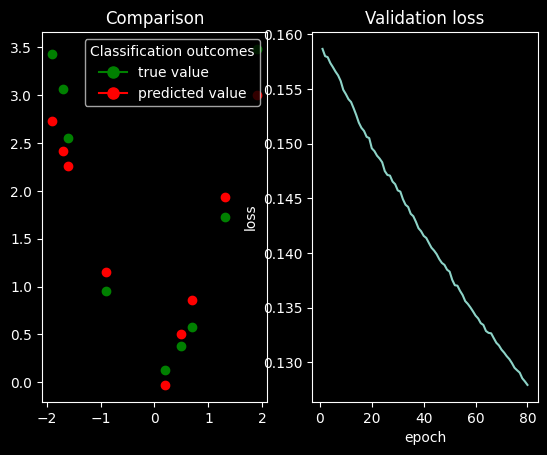

In [343]:
# for prediction, real_val in zip(predictions, y_test_f):
#     print(f"pred: {prediction}, real: {real_val}, delta: {abs(prediction - real_val)}")


# comparison plot
fig, (comparison, validation_loss) = plt.subplots(1, 2)
comparison.scatter(X_test_f, y_test_f, c="green")
comparison.scatter(X_test_f, predictions, c="red")

legend_elements = [
          Line2D([0], [0], marker='o', color='green', label='true value', markersize=8),
          Line2D([0], [0], marker='o', color='red', label='predicted value', markersize=8),
    ]

comparison.legend(handles=legend_elements, title="Classification outcomes", loc='upper right')
comparison.set_title("Comparison")

# validation loss plot
validation_loss_values = training_history.history["loss"]
validation_loss.plot(range(1, len(validation_loss_values) + 1), validation_loss_values)
validation_loss.set_xlabel("epoch")
validation_loss.set_ylabel("loss")
validation_loss.set_title("Validation loss")

from sklearn.metrics import mean_absolute_error
# accuracy metrics
mean_absolute_error = round(mean_absolute_error(y_test, predictions),3)
initial_loss = round(training_history.history["mse"][0], 5)
final_loss = round(training_history.history["mse"][number_of_epochs -1], 5)

print(f"For the regression problem a network with single hidden layer has been chosen. "
      "The layer has 6 neurons and a RELU activation function to prevent the linearity problem. "
      "In the training the ADAM function was used for recalculation of neurons weights. The training "
      "consisted of 80 epochs which is a local optimum, as a decline in accuracy over 100 epochs was observed. Additionally the batch size was set as one-forth of the train dataset size.\n"
      ""
      "Configuration has yielded following results:\n"
      f"- The mean absolute error of training test is {mean_absolute_error}\n"
      f"- The validation loss decreased from {initial_loss} observed after first epoch to {final_loss} observed after {number_of_epochs}th epoch.")

plt.show()